START -> retrieve -> generate -> END

여기서는 retrieve -> generate 사이에 사용자 질문을 검증해 유효하면 generate로 가고, 아니라면 rewrite하는 작업을 수행

In [1]:
%pip install -q langchain-chroma


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embeddings,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})



In [3]:
# START -> RETRIEVE -> GENERATE -> END

from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)

In [4]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}    

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [6]:
from langchain import hub

generate_prompt = hub.pull('rlm/rag-prompt')

def generate(state: AgentState) -> AgentState:
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response.content}

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [7]:
from langchain import hub
from typing import Literal

# 질문과 document의 연관성이 얼마나 되는지 확인하는 rag-document-relevance 프롬프트
doc_relevance_prompt = hub.pull('langchain-ai/rag-document-relevance')

# return type을 지정하지 않으면, 기본적으로 langchain은 state를 반환하는것으로 처리한다. 따라서, 노드가 무엇을 반환하는지 명시할 필요가 있다.
def check_doc_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    if response['Score'] == 1:
        return 'generate'
    return 'rewrite'

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [8]:
query = '연봉 5천만원 직장인의 소득세는?'

In [9]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
    사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    사전: {dictionary}
    질문: {{query}}
"""
)

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    return {'query': response}


In [10]:
# 노드 추가
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('check_doc_relevance', check_doc_relevance)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)


In [11]:
# 엣지 추가
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
# 아래 처럼 하면 의도되지 않은 순서의 그래프가 나온다.
#graph_builder.add_conditional_edges('retrieve', generate)
#graph_builder.add_conditional_edges('retrieve', rewrite)
graph_builder.add_conditional_edges('retrieve', check_doc_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)


In [12]:
graph = graph_builder.compile()

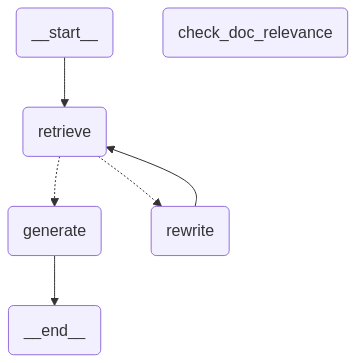

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [14]:
initial_state = {'query': '연봉 5천만원 세금'}
graph.invoke(initial_state)

{'query': '연봉 5천만원 세금',
 'context': [Document(id='6d83d22a-0bb6-42b9-a7d9-bfc2cc2cc5a2', metadata={'source': './documents/income_tax.txt'}, page_content='5. 삭제<2014. 1. 1.>\n6. 삭제<2014. 1. 1.>\n7. 삭제<2014. 1. 1.>\n8. 제104조의3에 따른 비사업용 토지  \n법제처  92    국가법령정보센터\n소득세법\n양도소득세표준\n|  구분           |  세율                              |\n|-----------------|------------------------------------|\n| 1,400만원 이하  | 16% 세트                           |\n| 1,400만원 초과  | 22만원 + (1,400만원 초과액 × 25%) 세트 |\n| 5,000만원 이하  | 1,124만원 + (5,000만원 초과액 × 34%) 세트 |\n| 5,000만원 초과  | 2,416만원 + (8,800만원 초과액 × 45%) 세트 |\n| 1억 원 초과     | 5,206만원 + (1억5천만원 초과액 × 48%) 세트 |\n| 3억 원 이하     | 1,942,406만원 + (3억 원 초과액 × 50%) 세트 |\n| 5억 원 이하     | 2,942,406만원 + (5억 원 초과액 × 52%) 세트 |\n| 10억 원 이하    | 4,942,406만원 + (10억 원 초과액 × 55%) 세트 |\n9. 제94조제1항제1호 및 다목에 따른 자산 중 자산의 비사입용 토지의 보유 현황을 고려하여 대통령령으로 정하는 자산\n양도소득세 자산\n|  구분           |  세율                             |\n|-----------------|-----------------------------------|\n| 1,400만